# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)

---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [29]:
# Importa las cuatro librerías con sus alias convencionales
# tu código aquí
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Una vez que las importes, descomenta estas líneas para verificar las versiones:
print(f'numpy  {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')
print("Matplotlib versión:", __import__('matplotlib').__version__)


numpy  1.26.4
pandas  2.1.4
seaborn 0.12.2
Matplotlib versión: 3.8.0


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [30]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'
# tu código aquí
stars = pd.read_csv('star_dataset.csv')

print( "---" * 40)
print( "   " * 8 +"CONTENIDO INICIAL DEL DATASET:" )
display(stars.head())

# Muestra las primeras 5 filas del DataFrame
# tu código aquí
print( "---" * 40)
print( "   " * 8 +"INFORMACIÓN GENERAL DE CADA ESTRELLA:" )
print( " " * 40)
print(stars.head())
print( "---" * 40)
print( "   " * 8 +"DIMENSIONES (FILAS , COLUMNAS):", stars.shape)
print("   " * 1 +"TIPO DE DATOS:")
print(stars.dtypes)
print( "---" * 40)

------------------------------------------------------------------------------------------------------------------------
                        CONTENIDO INICIAL DEL DATASET:


,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Altair,16.594171,9.979192,1.632650,7509.294247,A7V
1,Deneb,2600.490723,196002.627856,202.970526,8503.284796,A2Ia
2,Barnard's Star,6.052616,4.893716,0.222711,3165.959639,M4Ve
3,Polaris,322.601002,2196.241934,37.546813,6048.326915,F7Ib
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve


------------------------------------------------------------------------------------------------------------------------
                        INFORMACIÓN GENERAL DE CADA ESTRELLA:
                                        
             Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  \
0          Altair      16.594171           9.979192       1.632650   
1           Deneb    2600.490723      196002.627856     202.970526   
2  Barnard's Star       6.052616           4.893716       0.222711   
3         Polaris     322.601002        2196.241934      37.546813   
4  Barnard's Star       5.902392          -1.496486       0.192359   

   Temperature (K) Spectral Class  
0      7509.294247            A7V  
1      8503.284796           A2Ia  
2      3165.959639           M4Ve  
3      6048.326915           F7Ib  
4      3130.602069           M4Ve  
------------------------------------------------------------------------------------------------------------------------
                  

---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [31]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
# tu código aquí

stars = pd.read_csv('star_dataset.csv')
print( "..." * 40)
print( "   " * 15 +"DIMENSIONES (COLUMNAS, FILAS):\n" )
print(stars.shape)
print( "..." * 40)
print( "   " * 40)
print( "   " * 15 +"NOMBRE DE LAS COLUMNAS:\n")
print(stars.columns.tolist())
print( "   " * 40)
print( "..." * 40)
print("\n " + "   " * 15 +" TIPO DE DATOS:\n")
print(stars.dtypes)
print("..." * 40)



........................................................................................................................
                                             DIMENSIONES (COLUMNAS, FILAS):

(1000, 6)
........................................................................................................................
                                                                                                                        
                                             NOMBRE DE LAS COLUMNAS:

['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']
                                                                                                                        
........................................................................................................................

                                               TIPO DE DATOS:

Name                  object
Distance (ly)        float64
Luminosity (L/L

In [32]:
# Obtén el resumen estadístico de las columnas numéricas
# tu código aquí
stars = pd.read_csv('star_dataset.csv')
resumen = stars.describe()
resumen = resumen.rename(index={
    "count" : " NÚMERO TOTAL DE REGISTROS",
    "mean" : "PROMEDIO", 
    "std" : "DESVIACIÓN ESTÁNDAR",
    "min" : "VALOR MÍNIMO",
    "max" : "VALOR MÁXIMO", 
    "25%" : "CUARTIL 1 (25%)",   
    "50%" : "MEDIANA (50%)",
    "75%" : "CUARTIL 3 (75%)",
    "mod" : "MODA",  
})
print( "----" * 40)
print(" " * 15 + "ESTADÍSTICA DESCRIPTIVA DE LA DATASET: ESTRELLAS \n ")
print(resumen)


print( "----" * 40)
a = stars[stars['Luminosity (L/Lo)'] < 0]   # explica por que en el valor mínimo se obtuvo un valor negativo

print("   " * 15 + "LISTA DE DATOS EXTRAÑOS \n ")
print(f" Total de Datos Extraños por ser Negativos: {len(a)} ")
display(a)
print( "----" * 40)


----------------------------------------------------------------------------------------------------------------------------------------------------------------
               ESTADÍSTICA DESCRIPTIVA DE LA DATASET: ESTRELLAS 
 
                            Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  \
 NÚMERO TOTAL DE REGISTROS    1000.000000        1000.000000    1000.000000   
PROMEDIO                       295.505327       19644.909442      86.960696   
DESVIACIÓN ESTÁNDAR            541.478403       42223.595017     213.850005   
VALOR MÍNIMO                     3.877798          -4.993141       0.068087   
CUARTIL 1 (25%)                 11.716853          10.441039       1.664479   
MEDIANA (50%)                   52.031435         171.097809       5.845444   
CUARTIL 3 (75%)                322.865874       10500.577117      33.719778   
VALOR MÁXIMO                  2600.490723      196004.854081     887.097936   

                            Temperature (K)  
 NÚMERO TOTAL 

,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve
28,Alpha Centauri B,3.925939,-2.512424,0.897156,5292.710092,K1V
29,Ross 154,9.584936,-0.262213,0.098150,2788.607876,M3.5V
38,Barnard's Star,6.274309,-4.612504,0.271420,3164.713490,M4Ve
49,Barnard's Star,5.563557,-3.458955,0.149536,3115.066681,M4Ve
...,...,...,...,...,...,...
941,Wolf 359,7.509381,-4.935053,0.208109,2841.890593,M6V
944,Rigil Kentaurus,4.770200,-1.162515,1.211841,5768.601304,G2V
994,Barnard's Star,5.938952,-3.172254,0.266688,3121.980225,M4Ve
995,Wolf 359,7.455715,-4.435101,0.068087,2774.148300,M6V


----------------------------------------------------------------------------------------------------------------------------------------------------------------


En términos físicos, la luminosidad mide la cantidad de energía que emite una estrella por segundo. Al ser una medida de energía emitida, no puede ser negativa. Por eso se adjunta 

In [33]:
# Cuenta los valores nulos por columna
# tu código aquí

stars = pd.read_csv('star_dataset.csv')
a = stars.isnull().sum()
print(a)

Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64


---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [34]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
# tu código aquí
stars = pd.read_csv('star_dataset.csv')
conteo  = stars["Spectral Class"].value_counts() 
print(conteo)

Spectral Class
A7V         74
A1V         73
A9II        48
M3.5V       45
B1III       45
M2Iab       44
G8III       39
M4Ve        38
A0V         38
K1.5III     38
B2III       37
M7IIIe      37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
F5IV-V      30
B0.5IV      30
B6Vep       29
M2.1V       27
M1.5Iab     26
B7V         26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


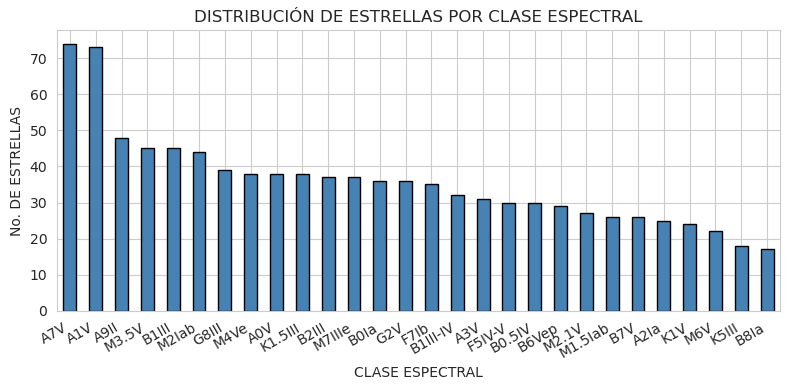

In [35]:
plt.figure(figsize=(8, 4))

# Crea la gráfica de barras con conteo.plot(kind='bar', color=..., edgecolor=...)
# tu código aquí
stars = pd.read_csv('star_dataset.csv')
conteo  = stars["Spectral Class"].value_counts() 
conteo.plot(kind='bar', color='steelblue', edgecolor='black')



# Agrega título y etiquetas de ejes
# tu código aquí

plt.title("DISTRIBUCIÓN DE ESTRELLAS POR CLASE ESPECTRAL")
plt.xlabel("CLASE ESPECTRAL")
plt.ylabel("No. DE ESTRELLAS")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [36]:
# ── Enfoque 1: ciclo for ──────────────────────────────────────────────────────
tipo_objetivo = 'A7V'
stars = pd.read_csv('star_dataset.csv')
# Paso 1: filtra el DataFrame para obtener solo las estrellas de tipo_objetivo (clase espectral)
# filtrado = ...
# tu código aquí
filtrado = stars[stars["Spectral Class"] ==  tipo_objetivo ]
print(filtrado)

# Paso 2: recorre filtrado['Temperature (K)'] con un for
# acumula la suma y el conteo (n)
# tu código aquí
suma_temperaturas = 0
conteo_n = 0
for temperaturas in filtrado['Temperature (K)']:
    suma_temperaturas += temperaturas
    conteo_n += 1

# Calcula la media y guárdala en media_manual
# media_manual = suma / n
# tu código aquí
if conteo_n > 0:
    media_manual = suma_temperaturas / conteo_n
    print(f"MEDIA DE TEMPERATURAS: {tipo_objetivo} : { media_manual } K")
else:
    print("DATOS NO EXISTENTES")


print(f'TEMPERATURA MEDIA (for loop) : {media_manual:,.1f} K')

       Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  Temperature (K)  \
0    Altair      16.594171           9.979192       1.632650      7509.294247   
11   Altair      16.324632          10.457079       1.638568      7554.538238   
32   Altair      16.977835           8.978259       1.681768      7546.776074   
41   Altair      16.481724          10.654505       1.697977      7557.224465   
82   Altair      17.004753          15.509654       1.574136      7589.018862   
..      ...            ...                ...            ...              ...   
974  Altair      16.502834          15.008535       1.537144      7531.390715   
984  Altair      17.154742           6.975772       1.548312      7537.641975   
989  Altair      17.111919          10.391013       1.609587      7504.094813   
990  Altair      16.874372           5.998471       1.559794      7561.789883   
993  Altair      17.121544          11.776187       1.635310      7555.418080   

    Spectral Class  
0     

Comparación: for vs. pandas:

Con el ciclo for calculaste la media de una sola clase espectral en varias líneas. Ahora verás cómo pandas obtiene la media de todas las clases a la vez en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de A7V coincida con el valor que obtuviste con el for.

In [37]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
# tu código aquí
print( "----" * 40)
stars = pd.read_csv('star_dataset.csv')
temp_por_tipo = stars.groupby('Spectral Class')['Temperature (K)'].mean().sort_values(ascending=False)
print('Temperatura promedio por clase espectral (K):')
print(temp_por_tipo)
print()
valor_pd = temp_por_tipo['A7V']
print(f"RESULTADO PANDAS ('A7V'): {valor_pd:,.6f} K")


# Imprime una línea de verificación comparando media_manual con el valor de groupby para 'A7V'
# tu código aquí
tipo_objetivo = 'A7V'
filtrado = stars[stars["Spectral Class"] ==  tipo_objetivo ]
suma_temperaturas = 0
conteo_n = 0
for temperaturas in filtrado['Temperature (K)']:
    suma_temperaturas += temperaturas
    conteo_n += 1

# Calcula la media y guárdala en media_manual
# media_manual = suma / n
# tu código aquí
if conteo_n > 0:
    media_manual = suma_temperaturas / conteo_n
   
else:
    print("DATOS NO EXISTENTES")
print( "----" * 40)
print("   " * 15 + "COMPARACIÓN DE LA MEDIA DE LOS VALORES 'A7V' (PANDAS,  CICLO FOR)   \n ")
valor_pd = temp_por_tipo['A7V']
print(f"RESULTADO PANDAS ('A7V'): {valor_pd:,.1f} K")
print(f"RESULTADO MANUAL('A7V'): {media_manual:,.1f} K")
print( "----" * 40)

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Temperatura promedio por clase espectral (K):
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
A3V          8584.693288
A2Ia         8516.840653
A7V          7550.178313
A9II         7349.223744
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
K1V          5261.645715
G8III        4939.733287
K1.5III      4280.090548
K5III        3923.614977
M2Iab        3502.196868
M1.5Iab      3499.130207
M2.1V        3408.914115
M4Ve         3136.076002
M7IIIe       2914.515688
M3.5V        2802.627176
M6V          2795.196060
Name: Temperature (K), dtype: float64

RESULTADO PANDAS ('A7V'): 7,550.178313 

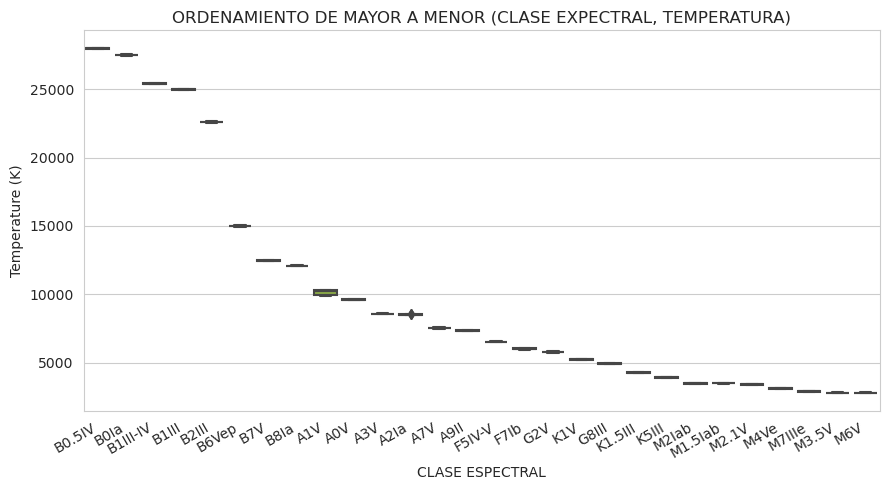

In [38]:
stars = pd.read_csv('star_dataset.csv')
plt.figure(figsize=(9, 5))
orden = temp_por_tipo.index   # orden de mayor a menor temperatura

# Crea el boxplot con sns.boxplot(data=..., x=..., y=..., order=...)
# tu código aquí
sns.boxplot(data=stars, x='Spectral Class', y='Temperature (K)', order=orden)


# Agrega título y etiquetas de ejes
# tu código aquí
plt.title("ORDENAMIENTO DE MAYOR A MENOR (CLASE EXPECTRAL, TEMPERATURA)")
plt.xlabel("CLASE ESPECTRAL")
plt.ylabel('Temperature (K)')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

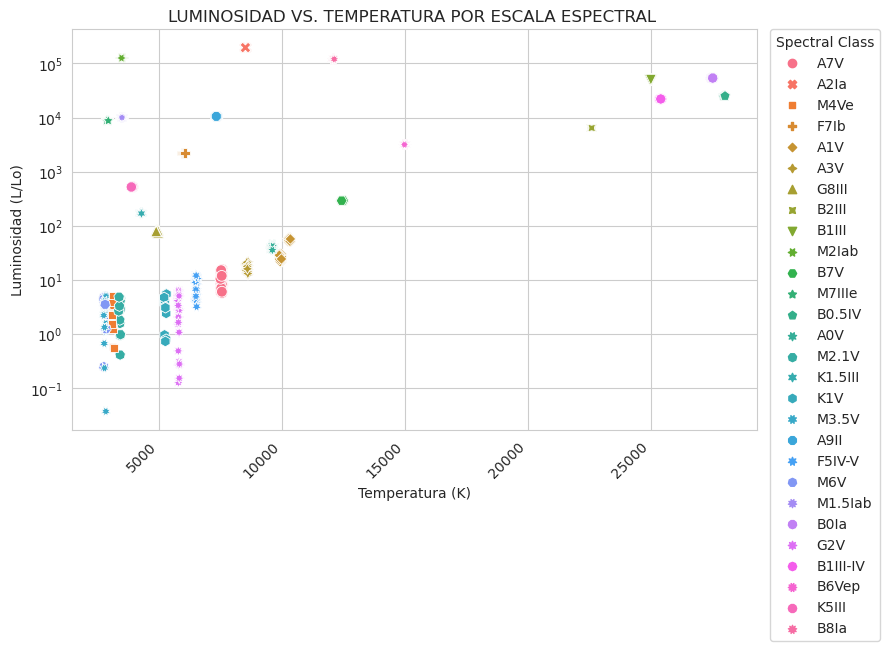

In [39]:
stars = pd.read_csv('star_dataset.csv')
plt.figure(figsize=(9, 6))

# Crea el scatter plot con sns.scatterplot(...)
# tu código aquí
sns.scatterplot(data=stars, 
                x='Temperature (K)', 
                y='Luminosity (L/Lo)', 
                hue='Spectral Class', 
                style='Spectral Class', 
                s=60)


# Aplica escala logarítmica al eje Y
# tu código aquí
plt.yscale('log')

# Agrega título, etiquetas de ejes y leyenda
# tu código aquí

plt.legend(title='Spectral Class', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.title('LUMINOSIDAD VS. TEMPERATURA POR ESCALA ESPECTRAL ')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')

plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [40]:
# Extrae los arrays NumPy con .values
# tu código aquí
stars = pd.read_csv('star_dataset.csv')
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius (R/Ro)'].values



# Imprime el tipo del array
# tu código aquí
print( "----" * 40)
print("TIPO DE VARIABLE")
print(type(temperaturas))

# Calcula e imprime: media, mediana, desv. estándar, mínima y máxima de temperaturas
# tu código aquí

print( "----" * 40)
print("  " * 15 + "ESTADÍSTICA BÁSICA")
print(f"\n a) Media de Temperaturas:  {np.mean(temperaturas):.2f}K")
print(f"\n b) Mediana de las Temperaturas:  {np.median(temperaturas):.2f}K")
print(f"\n c) Desviación Estándar de las Temperaturas:  {np.std(temperaturas):.2f}K")
print(f"\n d) Mínimo de Temperaturas:  {np.min(temperaturas):.2f}K")
print(f"\n e) Máximo de Temperaturas: {np.max(temperaturas):.2f}K")
print( "----" * 40)

----------------------------------------------------------------------------------------------------------------------------------------------------------------
TIPO DE VARIABLE
<class 'numpy.ndarray'>
----------------------------------------------------------------------------------------------------------------------------------------------------------------
                              ESTADÍSTICA BÁSICA

 a) Media de Temperaturas:  9983.49K

 b) Mediana de las Temperaturas:  7379.01K

 c) Desviación Estándar de las Temperaturas:  7903.02K

 d) Mínimo de Temperaturas:  2750.18K

 e) Máximo de Temperaturas: 28044.28K
----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [41]:
niveles = [25, 50, 75, 90]
stars = pd.read_csv('star_dataset.csv')
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius (R/Ro)'].values

# Calcula los percentiles del radio estelar con np.percentile(radios, niveles)
# tu código aquí
p = np.percentile(radios, niveles)

# Imprime cada percentil usando un ciclo for y zip(niveles, p)
# tu código aquí
print( "--" * 40)
print("  " * 15 + "PERCENTILES")
print( "    " * 40)
for nivel, valor_p in zip(niveles, p):
    print(f" Percentil {nivel}: {valor_p:.2f}")
   
print( "    " * 40)
# Convierte temperaturas de Kelvin a Celsius de forma vectorizada (sin for)
# celsius = ...
# tu código aquí
print( "--" * 40)
celcius = temperaturas - 273.15

# Imprime las primeras 5 temperaturas en K y en C para comparar
# (usa np.round para redondear a 1 decimal)
# tu código aquí
print( "    " * 40)
print("   " * 2 + "COMPARACIÓN DE LAS TEMPERATUARA DE LAS PRIMERAS 5 ESTRELLAS (K = °C)")
print(f"\n  1° Temperatura:  {temperaturas[0]:.3f} K  =  {celcius[0]:.3f} °C")
print(f"\n  2° temperatura:  {temperaturas[1]:.3f} K  =  {celcius[1]:.3f} °C")
print(f"\n  3° temperatura:  {temperaturas[2]:.3f} K  =  {celcius[2]:.3f} °C")
print(f"\n  4° temperatura:  {temperaturas[3]:.3f} K  =  {celcius[3]:.3f} °C")
print(f"\n  5° temperatura:  {temperaturas[4]:.3f} K  =  {celcius[4]:.3f} °C")

print( "--" * 40)





--------------------------------------------------------------------------------
                              PERCENTILES
                                                                                                                                                                
 Percentil 25: 1.66
 Percentil 50: 5.85
 Percentil 75: 33.72
 Percentil 90: 369.93
                                                                                                                                                                
--------------------------------------------------------------------------------
                                                                                                                                                                
      COMPARACIÓN DE LAS TEMPERATUARA DE LAS PRIMERAS 5 ESTRELLAS (K = °C)

  1° Temperatura:  7509.294 K  =  7236.144 °C

  2° temperatura:  8503.285 K  =  8230.135 °C

  3° temperatura:  3165.960 K  =  2892.810 °C

  4° temperat

---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

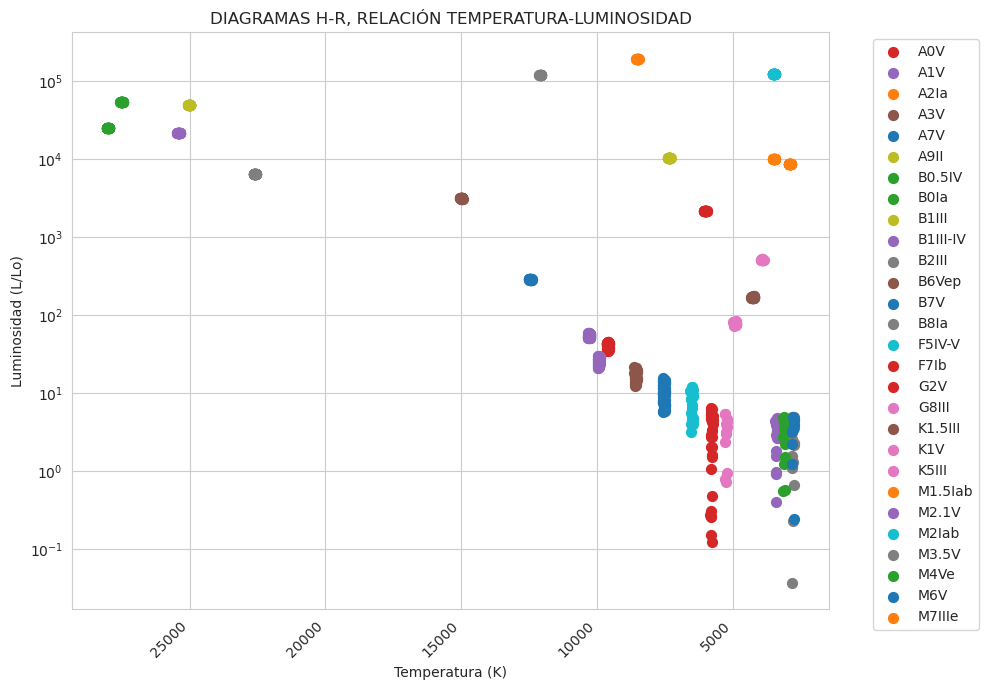

In [28]:
stars = pd.read_csv('star_dataset.csv')
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))
mapa    = dict(zip(tipos, colores))

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")


# Itera con stars.groupby('Spectral Class') y crea un plt.scatter() por cada tipo
# tu código aquí
for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'], grupo['Luminosity (L/Lo)'], label= tipo , color=mapa[tipo], s=50, alpha=1.0)


orden_clases = stars.groupby('Spectral Class')['Temperature (K)'].mean().sort_values(ascending=False).index

# Aplica escala logarítmica en ambos ejes (xscale y yscale)
# tu código aquí

plt.yscale("log")

# Invierte el eje X con plt.gca().invert_xaxis()
# tu código aquí
plt.gca().invert_xaxis()

# Agrega: título, etiquetas de ejes, leyenda y grid
# tu código aquí

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("DIAGRAMAS H-R, RELACIÓN TEMPERATURA-LUMINOSIDAD")
plt.xlabel("Temperatura (K)")
plt.ylabel("Luminosidad (L/Lo)")

plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()